# Comparación final de modelos usando TEST

Este notebook compara los modelos finales usando **solo el conjunto test**.

El flujo está organizado paso por paso:

1. Cargar librerías y rutas.
2. Crear pares positivos y negativos para test.
3. Limpiar código y calcular features.
4. Cargar modelos entrenados.
5. Evaluar cada modelo en test.
6. Crear el ranking final.
7. Visualizar métricas, matrices de confusión y errores.

`train` se usa para entrenar, `validation` para ajustar modelos y thresholds, y `test` para reportar las métricas finales.

## 1. Imports y rutas

Primero se cargan las librerías, se define la semilla de reproducibilidad y se preparan las carpetas de trabajo.

In [1]:
from pathlib import Path
from collections import Counter
import math
import random
import re
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 120)
warnings.filterwarnings('ignore')

# Semilla fija para que los resultados aleatorios sean reproducibles.
RANDOM_STATE = 42
# Rutas principales del proyecto.
DATASET_PATH = Path('data')
TEST_PATH = DATASET_PATH / 'test'
PROCESSED_PATH = DATASET_PATH / 'processed'
REPORTS_PATH = DATASET_PATH / 'reports'
MODELS_PATH = DATASET_PATH / 'models'
EMBEDDINGS_PATH = DATASET_PATH / 'embeddings'

for path in [PROCESSED_PATH, REPORTS_PATH, MODELS_PATH, EMBEDDINGS_PATH]:
    path.mkdir(parents=True, exist_ok=True)

print('Paso 1 completado: rutas listas.')
print('TEST_PATH existe:', TEST_PATH.exists())
print('Reportes existentes:', len(list(REPORTS_PATH.glob('*.csv'))))
print('Modelos existentes:', len(list(MODELS_PATH.glob('*'))))

Paso 1 completado: rutas listas.
TEST_PATH existe: True
Reportes existentes: 52
Modelos existentes: 11


## 2. Crear test etiquetado y sus features

Los `qrel` de test contienen pares positivos: archivos que sí tienen reuso.

Para evaluar modelos binarios también necesitamos negativos. Esta sección:

1. Lee los pares positivos.
2. Busca el código fuente de cada archivo.
3. Genera pares negativos balanceados por lenguaje y escenario.
4. Limpia y tokeniza el código.
5. Calcula features simples de similitud.
6. Guarda los archivos procesados que usarán los modelos.

In [2]:
def normalize_language(value):

    """Unifica nombres de lenguaje: cpp/c_cpp se tratan como c."""
    value = str(value).lower()
    return 'c' if value in {'c_cpp', 'cpp'} else value


def load_test_qrel(qrel_path, language):

    """Lee un qrel de test y crea pares positivos con label=1."""
    rows = []
    with open(qrel_path, 'r', encoding='utf-8', errors='ignore') as file:
        for line_number, line in enumerate(file, start=1):
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            file_1, file_2 = parts[0], parts[1]
            rows.append({
                'language': language,
                'scenario': file_1[:2] if file_1[:2] == file_2[:2] else 'unknown',
                'file_1': file_1,
                'file_2': file_2,
                'label': 1,
                'source_qrel': qrel_path.name,
                'line_number': line_number,
            })
    return pd.DataFrame(rows)


def attach_code_to_pairs(pairs_df, test_codes):

    """Agrega el código crudo y la ruta de archivo a cada par."""
    codes = test_codes.copy()
    codes['language'] = codes['language'].apply(normalize_language)
    codes['file_key'] = codes['file_id'].fillna(codes['file_name']).astype(str)
    code_map = codes.set_index(['language', 'file_key'])['code_raw'].to_dict()
    path_map = codes.set_index(['language', 'file_key'])['file_path'].to_dict()

    df = pairs_df.copy()
    df['code_1_raw'] = df.apply(lambda row: code_map.get((row['language'], row['file_1'])), axis=1)
    df['code_2_raw'] = df.apply(lambda row: code_map.get((row['language'], row['file_2'])), axis=1)
    df['path_1'] = df.apply(lambda row: path_map.get((row['language'], row['file_1'])), axis=1)
    df['path_2'] = df.apply(lambda row: path_map.get((row['language'], row['file_2'])), axis=1)
    return df.dropna(subset=['code_1_raw', 'code_2_raw']).reset_index(drop=True)


def pair_key(language, file_1, file_2):

    """Crea una clave única para un par, sin importar el orden."""
    return (language, tuple(sorted([str(file_1), str(file_2)])))


def generate_test_negative_pairs(test_codes, positive_pairs, seed=RANDOM_STATE):

    """Genera pares negativos sin repetir positivos ni pares ya usados."""
    rng = random.Random(seed)
    codes = test_codes.copy()
    codes['language'] = codes['language'].apply(normalize_language)
    codes['file_key'] = codes['file_id'].fillna(codes['file_name']).astype(str)
    positive_set = {pair_key(row.language, row.file_1, row.file_2) for row in positive_pairs.itertuples(index=False)}
    negatives = []
    used_set = set()

    for group in positive_pairs.groupby(['language', 'scenario']).size().reset_index(name='n').itertuples(index=False):
        pool = codes[(codes['language'] == group.language) & (codes['scenario'] == group.scenario)].copy()
        if len(pool) < 2:
            pool = codes[codes['language'] == group.language].copy()
        records = pool.to_dict(orient='records')
        created = 0
        attempts = 0
        max_attempts = max(int(group.n) * 200, 1000)
        while created < int(group.n) and attempts < max_attempts:
            attempts += 1
            row_1, row_2 = rng.sample(records, 2)
            key = pair_key(group.language, row_1['file_key'], row_2['file_key'])
            if key in positive_set or key in used_set:
                continue
            used_set.add(key)
            negatives.append({
                'language': group.language,
                'scenario': group.scenario,
                'file_1': row_1['file_key'],
                'file_2': row_2['file_key'],
                'path_1': row_1['file_path'],
                'path_2': row_2['file_path'],
                'code_1_raw': row_1['code_raw'],
                'code_2_raw': row_2['code_raw'],
                'label': 0,
                'source_qrel': 'generated_negative',
                'line_number': np.nan,
            })
            created += 1
        if created < int(group.n):
            print(f'Advertencia: solo se generaron {created}/{int(group.n)} negativos para {group.language}-{group.scenario}')
    return pd.DataFrame(negatives)


def build_test_raw_pairs():

    """Construye el dataset test crudo: positivos + negativos balanceados."""
    test_codes_path = PROCESSED_PATH / '00_test_codes_raw.csv'
    if not test_codes_path.exists():
        raise FileNotFoundError('Falta data/processed/00_test_codes_raw.csv. Ejecuta primero el notebook 01.')
    test_codes = pd.read_csv(test_codes_path)
    test_codes['language'] = test_codes['language'].apply(normalize_language)
    print('  - Leyendo qrels positivos de C/C++ y Java...')
    positives = pd.concat([
        load_test_qrel(TEST_PATH / 'soco14-test-c-update.qrel', 'c'),
        load_test_qrel(TEST_PATH / 'soco14-test-java-update.qrel', 'java'),
    ], ignore_index=True)
    positives = attach_code_to_pairs(positives, test_codes)
    print('  - Pares positivos con código:', len(positives))
    print('  - Generando pares negativos balanceados...')
    negatives = generate_test_negative_pairs(test_codes, positives)
    print('  - Pares negativos generados:', len(negatives))
    test_pairs = pd.concat([positives, negatives], ignore_index=True)
    test_pairs = test_pairs.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    test_pairs['pair_id'] = [f'test_pair_{i:06d}' for i in range(len(test_pairs))]
    cols = ['pair_id', 'language', 'scenario', 'file_1', 'file_2', 'path_1', 'path_2', 'code_1_raw', 'code_2_raw', 'label', 'source_qrel', 'line_number']
    test_pairs = test_pairs[cols]
    test_pairs.to_csv(PROCESSED_PATH / '01_test_pairs_raw.csv', index=False)
    return test_pairs

JAVA_C_KEYWORDS = {
    'auto', 'break', 'case', 'char', 'const', 'continue', 'default', 'do', 'double', 'else', 'enum', 'extern',
    'float', 'for', 'goto', 'if', 'int', 'long', 'register', 'return', 'short', 'signed', 'sizeof', 'static',
    'struct', 'switch', 'typedef', 'union', 'unsigned', 'void', 'volatile', 'while', 'class', 'public', 'private',
    'protected', 'template', 'typename', 'using', 'namespace', 'new', 'delete', 'this', 'virtual', 'operator',
    'include', 'iostream', 'std', 'cin', 'cout', 'endl', 'abstract', 'assert', 'boolean', 'byte', 'catch',
    'extends', 'final', 'finally', 'implements', 'import', 'instanceof', 'interface', 'native', 'null', 'package',
    'strictfp', 'super', 'synchronized', 'throws', 'throw', 'transient', 'try', 'true', 'false', 'String', 'System',
    'Scanner', 'ArrayList', 'HashMap', 'Math', 'Integer', 'Double', 'Long'
}
TOKEN_PATTERN = re.compile(r'"(?:\\.|[^"\\])*"' r"|'(?:\\.|[^'\\])*'" r'|\b\d+(?:\.\d+)?\b' r'|\b[A-Za-z_][A-Za-z0-9_]*\b' r'|==|!=|<=|>=|\+\+|--|&&|\|\||<<|>>' r'|[{}\[\]();,.:?]' r'|[+\-*/%=&|!<>^~]')


def limpieza_ligera(code):

    """Normaliza saltos de línea y espacios sin modificar la lógica."""
    if not isinstance(code, str):
        return ''
    code = code.replace('\r\n', '\n').replace('\r', '\n')
    code = '\n'.join(line.rstrip() for line in code.split('\n'))
    code = re.sub(r'\n{3,}', '\n\n', code)
    return code.strip()


def remove_c_java_comments(code):

    """Quita comentarios de C/C++/Java para comparar mejor la estructura."""
    if not isinstance(code, str):
        return ''
    code = re.sub(r'/\*.*?\*/', ' ', code, flags=re.DOTALL)
    code = re.sub(r'//.*', ' ', code)
    return limpieza_ligera(code)


def lexical_tokens(code):

    """Extrae tokens léxicos sencillos del código."""
    return TOKEN_PATTERN.findall(code) if isinstance(code, str) else []


def normalize_token(token):

    """Generaliza strings, chars, números e identificadores."""
    if re.fullmatch(r'"(?:\\.|[^"\\])*"', token):
        return 'STR'
    if re.fullmatch(r"'(?:\\.|[^'\\])*'", token):
        return 'CHAR'
    if re.fullmatch(r'\d+(?:\.\d+)?', token):
        return 'NUM'
    if re.fullmatch(r'[A-Za-z_][A-Za-z0-9_]*', token):
        return token.upper() if token in JAVA_C_KEYWORDS else 'ID'
    return token


def normalized_token_sequence(code):

    """Convierte el código en una secuencia de tokens normalizados."""
    return ' '.join(normalize_token(tok) for tok in lexical_tokens(code))


def raw_token_sequence(code):

    """Convierte el código en una secuencia de tokens originales."""
    return ' '.join(lexical_tokens(code))


def jaccard_similarity(a, b):

    """Mide similitud entre conjuntos de tokens."""
    set_a, set_b = set(str(a).split()), set(str(b).split())
    if not set_a and not set_b:
        return 1.0
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


def token_overlap_ratio(a, b):

    """Mide solapamiento de tokens contando repeticiones."""
    tokens_a, tokens_b = str(a).split(), str(b).split()
    if not tokens_a or not tokens_b:
        return 0.0
    overlap = sum((Counter(tokens_a) & Counter(tokens_b)).values())
    return overlap / min(len(tokens_a), len(tokens_b))


def preprocess_pairs(df):

    """Limpia, tokeniza y calcula features numéricas para cada par."""
    df = df.copy()
    df['code_1_clean'] = df['code_1_raw'].apply(limpieza_ligera)
    df['code_2_clean'] = df['code_2_raw'].apply(limpieza_ligera)
    df['code_1_no_comments'] = df['code_1_clean'].apply(remove_c_java_comments)
    df['code_2_no_comments'] = df['code_2_clean'].apply(remove_c_java_comments)
    df['code_1_tokens'] = df['code_1_no_comments'].apply(raw_token_sequence)
    df['code_2_tokens'] = df['code_2_no_comments'].apply(raw_token_sequence)
    df['code_1_norm'] = df['code_1_no_comments'].apply(normalized_token_sequence)
    df['code_2_norm'] = df['code_2_no_comments'].apply(normalized_token_sequence)
    df['code_1_token_count'] = df['code_1_norm'].apply(lambda x: len(x.split()))
    df['code_2_token_count'] = df['code_2_norm'].apply(lambda x: len(x.split()))
    df['jaccard_norm'] = df.apply(lambda row: jaccard_similarity(row['code_1_norm'], row['code_2_norm']), axis=1)
    df['token_overlap_norm'] = df.apply(lambda row: token_overlap_ratio(row['code_1_norm'], row['code_2_norm']), axis=1)
    df['abs_token_count_diff'] = (df['code_1_token_count'] - df['code_2_token_count']).abs()
    df['relative_token_count_diff'] = df['abs_token_count_diff'] / df[['code_1_token_count', 'code_2_token_count']].max(axis=1).replace(0, 1)
    return df


print('Paso 2.1: construyendo pares positivos y negativos de test...')
test_pairs_raw = build_test_raw_pairs()
print('Paso 2.2: limpiando código, tokenizando y calculando features...')
test_preprocessed = preprocess_pairs(test_pairs_raw)
test_preprocessed.to_csv(PROCESSED_PATH / '02_test_preprocessed.csv', index=False)

baseline_columns = ['pair_id', 'language', 'file_1', 'file_2', 'code_1_norm', 'code_2_norm', 'jaccard_norm', 'token_overlap_norm', 'relative_token_count_diff', 'label']
transformer_columns = ['pair_id', 'language', 'file_1', 'file_2', 'code_1_clean', 'code_2_clean', 'label']
test_baseline = test_preprocessed[baseline_columns].copy()
test_transformer = test_preprocessed[transformer_columns].copy()
test_baseline.to_csv(PROCESSED_PATH / '02_test_baseline.csv', index=False)
test_transformer.to_csv(PROCESSED_PATH / '02_test_transformer.csv', index=False)

print('Paso 2 completado: datasets de test guardados en data/processed.')

print('Pares test:', test_pairs_raw.shape)
display(test_pairs_raw['label'].value_counts().rename('conteo'))
display(test_pairs_raw.groupby(['language', 'label']).size().rename('conteo'))

Paso 2.1: construyendo pares positivos y negativos de test...
  - Leyendo qrels positivos de C/C++ y Java...
  - Pares positivos con código: 497
  - Generando pares negativos balanceados...
  - Pares negativos generados: 497
Paso 2.2: limpiando código, tokenizando y calculando features...
Paso 2 completado: datasets de test guardados en data/processed.
Pares test: (994, 12)


label
0    497
1    497
Name: conteo, dtype: int64

language  label
c         0        278
          1        278
java      0        219
          1        219
Name: conteo, dtype: int64

## 3. Funciones auxiliares para evaluar modelos guardados

Estas funciones preparan las entradas de los modelos, calculan métricas, guardan predicciones y cargan o generan embeddings CodeBERT para test.

In [4]:
numeric_feature_columns = ['jaccard_norm', 'token_overlap_norm', 'relative_token_count_diff']

def evaluate_binary_predictions(stage, family, model_name, y_true, y_pred, threshold=np.nan):

    """Calcula accuracy, precision, recall, F1 y matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        'source_split': 'test', 'stage': stage, 'family': family, 'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'tn': int(cm[0, 0]), 'fp': int(cm[0, 1]), 'fn': int(cm[1, 0]), 'tp': int(cm[1, 1]),
        'threshold': threshold,
    }


def save_predictions(df, y_pred, y_true, file_name, score_name=None, scores=None, threshold=np.nan):

    """Guarda predicciones por par para revisarlas después."""
    out = df[['pair_id', 'language', 'file_1', 'file_2']].copy()
    out['prediction'] = y_pred.astype(int)
    out['prediction_label'] = out['prediction'].map({0: 'No reuso', 1: 'Reuso'})
    out['true_label'] = y_true.astype(int)
    if score_name is not None and scores is not None:
        out[score_name] = scores
    if not pd.isna(threshold):
        out['threshold'] = threshold
    out.to_csv(REPORTS_PATH / file_name, index=False)
    return out


def build_tfidf_feature_matrix(df, vectorizer, numeric_cols):

    """Reconstruye la matriz de features TF-IDF usada por los modelos clásicos."""
    X1 = vectorizer.transform(df['code_1_norm'].fillna(''))
    X2 = vectorizer.transform(df['code_2_norm'].fillna(''))
    X_abs_diff = abs(X1 - X2)
    X_numeric = csr_matrix(df[numeric_cols].fillna(0).astype(float).values)
    return hstack([X1, X2, X_abs_diff, X_numeric]).tocsr()


def rowwise_cosine(a, b):

    """Calcula similitud coseno fila por fila entre dos matrices de embeddings."""
    numerator = np.sum(a * b, axis=1)
    denominator = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    denominator = np.where(denominator == 0, 1e-8, denominator)
    return numerator / denominator


def rowwise_l2(a, b):

    """Calcula distancia L2 fila por fila entre dos matrices de embeddings."""
    return np.linalg.norm(a - b, axis=1)


def build_embedding_features(emb1, emb2, include_l2=False):

    """Combina embeddings en las features que esperan los modelos entrenados."""
    # Se usan ambos embeddings, su diferencia, su producto y su similitud coseno.
    parts = [emb1, emb2, np.abs(emb1 - emb2), emb1 * emb2, rowwise_cosine(emb1, emb2).reshape(-1, 1)]
    if include_l2:
        parts.append(rowwise_l2(emb1, emb2).reshape(-1, 1))
    return np.hstack(parts)


def load_or_create_codebert_test_embeddings(model_name='microsoft/codebert-base', max_length=256, batch_size=8):

    """Carga embeddings desde caché o los crea con CodeBERT si no existen."""
    safe_model_name = model_name.replace('/', '_').replace('-', '_')
    suffix = f'{safe_model_name}_len{max_length}'
    emb1_path = EMBEDDINGS_PATH / f'test_emb1_{suffix}.npy'
    emb2_path = EMBEDDINGS_PATH / f'test_emb2_{suffix}.npy'
    if emb1_path.exists() and emb2_path.exists():
        print('Cargando embeddings de test desde cache.')
        return np.load(emb1_path), np.load(emb2_path)
    try:
        import torch
        from transformers import AutoTokenizer, AutoModel
    except Exception as exc:
        print('No se pueden generar embeddings de test:', repr(exc))
        return None, None

    @torch.no_grad()
    def encode_texts(texts, tokenizer, model, max_length=256, batch_size=8, device='cpu'):
        embeddings = []
        n_batches = math.ceil(len(texts) / batch_size)
        for i in range(n_batches):
            batch = texts[i * batch_size:(i + 1) * batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
            encoded = {key: value.to(device) for key, value in encoded.items()}
            outputs = model(**encoded)
            embeddings.append(outputs.last_hidden_state[:, 0, :].detach().cpu().numpy())
            if (i + 1) % 10 == 0 or (i + 1) == n_batches:
                print(f'Batch {i + 1}/{n_batches}')
        return np.vstack(embeddings)

    try:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        transformer_model = AutoModel.from_pretrained(model_name)
        transformer_model.to(device)
        transformer_model.eval()
        emb1 = encode_texts(test_transformer['code_1_clean'].fillna('').tolist(), tokenizer, transformer_model, max_length, batch_size, device)
        emb2 = encode_texts(test_transformer['code_2_clean'].fillna('').tolist(), tokenizer, transformer_model, max_length, batch_size, device)
        np.save(emb1_path, emb1)
        np.save(emb2_path, emb2)
        return emb1, emb2
    except Exception as exc:
        print('No se pudieron generar embeddings de test:', repr(exc))
        return None, None


def append_if_not_none(results, value):

    """Agrega un resultado solo cuando la evaluación sí se pudo ejecutar."""
    if value is not None:
        results.append(value)

In [5]:
def eval_03():
    print('Evaluando 03: baseline TF-IDF...')
    path = MODELS_PATH / '03_baseline_model.joblib'
    if not path.exists():
        print('Falta 03_baseline_model.joblib')
        return None
    bundle = joblib.load(path)
    model = bundle['model']
    numeric_cols = bundle.get('numeric_feature_columns', numeric_feature_columns)
    if bundle.get('best_model_type', 'tfidf_full') == 'tfidf_full':
        X = build_tfidf_feature_matrix(test_baseline, bundle['tfidf'], numeric_cols)
    else:
        X = test_baseline[numeric_cols].fillna(0).astype(float).values
    y = test_baseline['label'].astype(int).values
    pred = model.predict(X).astype(int)
    scores, score_name = None, None
    if hasattr(model, 'predict_proba'):
        scores, score_name = model.predict_proba(X)[:, 1], 'prob_reuse'
    elif hasattr(model, 'decision_function'):
        scores, score_name = model.decision_function(X), 'decision_score'
    save_predictions(test_baseline, pred, y, '03_test_predictions_baseline.csv', score_name, scores)
    return evaluate_binary_predictions('03_baseline_tfidf', 'TF-IDF clásico', bundle.get('best_model_name', 'Baseline TF-IDF'), y, pred)

In [6]:
def eval_04(emb1, emb2):
    print('Evaluando 04: embeddings CodeBERT...')
    if emb1 is None or emb2 is None:
        print('Se omite 04: no hay embeddings de test.')
        return None
    path = MODELS_PATH / '04_transformer_embedding_model.joblib'
    if not path.exists():
        print('Falta 04_transformer_embedding_model.joblib')
        return None
    bundle = joblib.load(path)
    model = bundle['classifier']
    X = build_embedding_features(emb1, emb2, include_l2=False)
    y = test_transformer['label'].astype(int).values
    pred = model.predict(X).astype(int)
    scores, score_name = None, None
    if hasattr(model, 'predict_proba'):
        scores, score_name = model.predict_proba(X)[:, 1], 'prob_reuse'
    elif hasattr(model, 'decision_function'):
        scores, score_name = model.decision_function(X), 'decision_score'
    out = save_predictions(test_transformer, pred, y, '04_test_predictions_transformer_embeddings.csv', score_name, scores)
    out['cosine_similarity'] = rowwise_cosine(emb1, emb2)
    out.to_csv(REPORTS_PATH / '04_test_predictions_transformer_embeddings.csv', index=False)
    return evaluate_binary_predictions('04_codebert_embeddings', 'Embeddings CodeBERT', bundle.get('best_model_name', 'Embedding classifier'), y, pred)

In [7]:
def eval_05(emb1, emb2):
    print('Evaluando 05: MLP sobre embeddings...')
    if emb1 is None or emb2 is None:
        print('Se omite 05: no hay embeddings de test.')
        return None
    model_path = MODELS_PATH / '05_custom_mlp_final.keras'
    meta_path = MODELS_PATH / '05_custom_mlp_metadata.joblib'
    if not model_path.exists() or not meta_path.exists():
        print('Falta modelo o metadata de 05.')
        return None
    try:
        from tensorflow.keras.models import load_model
    except Exception as exc:
        print('Se omite 05: TensorFlow no disponible:', repr(exc))
        return None
    meta = joblib.load(meta_path)
    model = load_model(model_path)
    X = build_embedding_features(emb1, emb2, include_l2=meta.get('feature_config', {}).get('USE_L2_DISTANCE', True))
    if meta.get('scaler') is not None:
        X = meta['scaler'].transform(X)
    threshold = float(meta.get('best_threshold', 0.5))
    y = test_transformer['label'].astype(int).values
    prob = model.predict(X, verbose=0).ravel()
    pred = (prob >= threshold).astype(int)
    save_predictions(test_transformer, pred, y, '05_custom_mlp_test_predictions.csv', 'prob_reuse', prob, threshold)
    return evaluate_binary_predictions('05_custom_mlp_embeddings', 'MLP sobre embeddings', 'Custom MLP', y, pred, threshold)

In [8]:
def eval_06(emb1, emb2):
    print('Evaluando 06: híbrido embeddings + baseline...')
    if emb1 is None or emb2 is None:
        print('Se omite 06: no hay embeddings de test.')
        return None
    path = MODELS_PATH / '06_hybrid_model.joblib'
    if not path.exists():
        print('Falta 06_hybrid_model.joblib')
        return None
    bundle = joblib.load(path)
    model = bundle['classifier']
    numeric_cols = bundle.get('numeric_feature_columns', numeric_feature_columns)
    X = np.hstack([build_embedding_features(emb1, emb2, include_l2=True), test_baseline[numeric_cols].fillna(0).astype(float).values])
    y = test_baseline['label'].astype(int).values
    pred = model.predict(X).astype(int)
    scores, score_name = None, None
    if hasattr(model, 'predict_proba'):
        scores, score_name = model.predict_proba(X)[:, 1], 'prob_reuse'
    elif hasattr(model, 'decision_function'):
        scores, score_name = model.decision_function(X), 'decision_score'
    out = save_predictions(test_baseline, pred, y, '06_hybrid_test_predictions.csv', score_name, scores)
    out['cosine_similarity'] = rowwise_cosine(emb1, emb2)
    out['l2_distance'] = rowwise_l2(emb1, emb2)
    for col in numeric_cols:
        out[col] = test_baseline[col].values
    out.to_csv(REPORTS_PATH / '06_hybrid_test_predictions.csv', index=False)
    return evaluate_binary_predictions('06_hybrid_embeddings_baseline', 'Híbrido embeddings + baseline', bundle.get('best_model_name', 'Hybrid classifier'), y, pred)

In [9]:
def eval_07():
    print('Evaluando 07: MLP Keras sobre TF-IDF...')
    model_path = MODELS_PATH / '07_tfidf_keras_mlp_final.keras'
    meta_path = MODELS_PATH / '07_tfidf_keras_metadata.joblib'
    if not model_path.exists() or not meta_path.exists():
        print('Falta modelo o metadata de 07.')
        return None
    try:
        from tensorflow.keras.models import load_model
    except Exception as exc:
        print('Se omite 07: TensorFlow no disponible:', repr(exc))
        return None
    meta = joblib.load(meta_path)
    model = load_model(model_path)
    numeric_cols = meta.get('numeric_feature_columns', numeric_feature_columns)
    X_sparse = build_tfidf_feature_matrix(test_baseline, meta['tfidf'], numeric_cols)
    X = meta['scaler'].transform(X_sparse).toarray().astype('float32')
    threshold = float(meta.get('best_threshold', 0.5))
    y = test_baseline['label'].astype(int).values
    prob = model.predict(X, verbose=0).ravel()
    pred = (prob >= threshold).astype(int)
    save_predictions(test_baseline, pred, y, '07_tfidf_keras_test_predictions.csv', 'prob_reuse', prob, threshold)
    return evaluate_binary_predictions('07_tfidf_keras_mlp', 'MLP Keras sobre TF-IDF', 'TF-IDF Keras MLP', y, pred, threshold)

In [34]:
def eval_08(emb1, emb2):
    print('Evaluando 08: embeddings CodeBERTa...')
    if emb1 is None or emb2 is None:
        print('Se omite 08: no hay embeddings de test.')
        return None
    path = MODELS_PATH / 'CodeBERTa_transformer_embedding_model.joblib'
    if not path.exists():
        print('Falta CodeBERTa_transformer_embedding_model.joblib')
        return None
    bundle = joblib.load(path)
    model = bundle['classifier']
    X = build_embedding_features(emb1, emb2, include_l2=False)
    y = test_transformer['label'].astype(int).values
    pred = model.predict(X).astype(int)
    scores, score_name = None, None
    if hasattr(model, 'predict_proba'):
        scores, score_name = model.predict_proba(X)[:, 1], 'prob_reuse'
    elif hasattr(model, 'decision_function'):
        scores, score_name = model.decision_function(X), 'decision_score'
    out = save_predictions(test_transformer, pred, y, '08_test_predictions_CodeBERTa_embeddings.csv', score_name, scores)
    out['cosine_similarity'] = rowwise_cosine(emb1, emb2)
    out.to_csv(REPORTS_PATH / '08_test_predictions_CodeBERTa_embeddings.csv', index=False)
    return evaluate_binary_predictions('08_CodeBERTa_embeddings', 'Embeddings CodeBERTa', bundle.get('best_model_name', 'Embedding classifier'), y, pred)

In [35]:
def eval_09(emb1, emb2):
    print('Evaluando 09: embeddings CodeGPT...')
    if emb1 is None or emb2 is None:
        print('Se omite 09: no hay embeddings de test.')
        return None
    path = MODELS_PATH / 'CodeGPT_transformer_embedding_model.joblib'
    if not path.exists():
        print('Falta CodeGPT_transformer_embedding_model.joblib')
        return None
    bundle = joblib.load(path)
    model = bundle['classifier']
    X = build_embedding_features(emb1, emb2, include_l2=False)
    y = test_transformer['label'].astype(int).values
    pred = model.predict(X).astype(int)
    scores, score_name = None, None
    if hasattr(model, 'predict_proba'):
        scores, score_name = model.predict_proba(X)[:, 1], 'prob_reuse'
    elif hasattr(model, 'decision_function'):
        scores, score_name = model.decision_function(X), 'decision_score'
    out = save_predictions(test_transformer, pred, y, '09_test_predictions_CodeGPT_embeddings.csv', score_name, scores)
    out['cosine_similarity'] = rowwise_cosine(emb1, emb2)
    out.to_csv(REPORTS_PATH / '09_test_predictions_CodeGPT_embeddings.csv', index=False)
    return evaluate_binary_predictions('09_CodeGPT_embeddings', 'Embeddings CodeGPT', bundle.get('best_model_name', 'Embedding classifier'), y, pred)

In [36]:
def eval_10(emb1, emb2):
    print('Evaluando 10: embeddings GraphCodeBert...')
    if emb1 is None or emb2 is None:
        print('Se omite 10: no hay embeddings de test.')
        return None
    path = MODELS_PATH / 'GraphCodeBert_transformer_embedding_model.joblib'
    if not path.exists():
        print('Falta GraphCodeBert_transformer_embedding_model.joblib')
        return None
    bundle = joblib.load(path)
    model = bundle['classifier']
    X = build_embedding_features(emb1, emb2, include_l2=False)
    y = test_transformer['label'].astype(int).values
    pred = model.predict(X).astype(int)
    scores, score_name = None, None
    if hasattr(model, 'predict_proba'):
        scores, score_name = model.predict_proba(X)[:, 1], 'prob_reuse'
    elif hasattr(model, 'decision_function'):
        scores, score_name = model.decision_function(X), 'decision_score'
    out = save_predictions(test_transformer, pred, y, '10_test_predictions_GraphCodeBert_embeddings.csv', score_name, scores)
    out['cosine_similarity'] = rowwise_cosine(emb1, emb2)
    out.to_csv(REPORTS_PATH / '10_test_predictions_GraphCodeBert_embeddings.csv', index=False)
    return evaluate_binary_predictions('10_GraphCodeBert_embeddings', 'Embeddings GraphCodeBert', bundle.get('best_model_name', 'Embedding classifier'), y, pred)

## 4. Ejecutar evaluaciones en TEST

Aquí se corren los modelos disponibles. Si falta un modelo o una dependencia pesada, se muestra un mensaje y el notebook continúa con los demás.

In [37]:
test_results = []
print('Paso 4.1: evaluando modelos que no necesitan embeddings externos...')
append_if_not_none(test_results, eval_03())

print('Paso 4.2: cargando o creando embeddings CodeBERT para test...')
emb1, emb2 = load_or_create_codebert_test_embeddings()

print('Paso 4.3: evaluando modelos basados en embeddings y modelos restantes...')
append_if_not_none(test_results, eval_04(emb1, emb2))
append_if_not_none(test_results, eval_05(emb1, emb2))
append_if_not_none(test_results, eval_06(emb1, emb2))
append_if_not_none(test_results, eval_07())
append_if_not_none(test_results, eval_08(emb1, emb2))
append_if_not_none(test_results, eval_09(emb1, emb2))
append_if_not_none(test_results, eval_10(emb1, emb2))


test_results_df = pd.DataFrame(test_results)
if test_results_df.empty:
    raise RuntimeError('No se evaluó ningún modelo en test. Revisa modelos guardados y dependencias.')

test_results_df = test_results_df.sort_values(['f1', 'recall', 'precision', 'accuracy'], ascending=False).reset_index(drop=True)
test_results_df.to_csv(REPORTS_PATH / 'comparation_test_model_results.csv', index=False)

print('Paso 4 completado: métricas de modelos guardadas.')
display(test_results_df)

Paso 4.1: evaluando modelos que no necesitan embeddings externos...
Evaluando 03: baseline TF-IDF...
Paso 4.2: cargando o creando embeddings CodeBERT para test...
Cargando embeddings de test desde cache.
Paso 4.3: evaluando modelos basados en embeddings y modelos restantes...
Evaluando 04: embeddings CodeBERT...
Evaluando 05: MLP sobre embeddings...
Evaluando 06: híbrido embeddings + baseline...
Evaluando 07: MLP Keras sobre TF-IDF...
Evaluando 08: embeddings CodeBERTa...
Evaluando 09: embeddings CodeGPT...
Evaluando 10: embeddings GraphCodeBert...
Paso 4 completado: métricas de modelos guardadas.


,source_split,stage,family,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold
0,test,03_baseline_tfidf,TF-IDF clásico,Linear SVM,0.921529,0.896030,0.953722,0.923977,442,55,23,474,NaN
1,test,06_hybrid_embeddings_baseline,Híbrido embeddings + baseline,Hybrid Random Forest,0.909457,0.939525,0.875252,0.906250,469,28,62,435,NaN
2,test,04_codebert_embeddings,Embeddings CodeBERT,Embedding Random Forest,0.890342,0.933036,0.841046,0.884656,467,30,79,418,NaN
3,test,05_custom_mlp_embeddings,MLP sobre embeddings,Custom MLP,0.883300,0.886410,0.879276,0.882828,441,56,60,437,0.40
4,test,10_GraphCodeBert_embeddings,Embeddings GraphCodeBert,Embedding Random Forest,0.506036,0.503036,1.000000,0.669360,6,491,0,497,NaN
5,test,08_CodeBERTa_embeddings,Embeddings CodeBERTa,Embedding Logistic Regression,0.500000,0.500000,1.000000,0.666667,0,497,0,497,NaN
6,test,07_tfidf_keras_mlp,MLP Keras sobre TF-IDF,TF-IDF Keras MLP,0.677062,0.766667,0.509054,0.611850,420,77,244,253,0.45
7,test,09_CodeGPT_embeddings,Embeddings CodeGPT,Embedding Logistic Regression,0.500000,0.000000,0.000000,0.000000,497,0,497,0,NaN


## 5. Ranking final con TEST

Esta es la comparación principal. Primero se ordena por F1, luego por recall, precision y accuracy.

La aserción impide que entre cualquier resultado que no venga de test.

In [38]:
all_candidates = test_results_df.copy()
assert all_candidates['source_split'].eq('test').all(), 'El ranking final contiene resultados que no son de test.'

cols = ['source_split', 'stage', 'family', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp', 'threshold']
all_candidates = all_candidates[cols].sort_values(['f1', 'recall', 'precision', 'accuracy'], ascending=False).reset_index(drop=True)
best_by_stage = all_candidates.groupby('stage', as_index=False).head(1).sort_values(['f1', 'recall', 'precision', 'accuracy'], ascending=False).reset_index(drop=True)
best_overall = all_candidates.iloc[0].copy()

all_candidates.to_csv(REPORTS_PATH / 'comparation_test_all_model_candidates.csv', index=False)
best_by_stage.to_csv(REPORTS_PATH / 'comparation_test_best_by_stage.csv', index=False)
best_overall.to_frame().T.to_csv(REPORTS_PATH / 'comparation_test_best_overall.csv', index=False)
best_overall.to_frame().T.to_csv(REPORTS_PATH / 'comparation_test_selected_final_model.csv', index=False)

print('Paso 5 completado: ranking final guardado.')
display(all_candidates)
print('Mejor modelo global en TEST:', best_overall['model'])
print('Etapa:', best_overall['stage'])
print('F1 test:', round(best_overall['f1'], 4))
print('Recall test:', round(best_overall['recall'], 4))
print('Precision test:', round(best_overall['precision'], 4))

Paso 5 completado: ranking final guardado.


,source_split,stage,family,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold
0,test,03_baseline_tfidf,TF-IDF clásico,Linear SVM,0.921529,0.896030,0.953722,0.923977,442,55,23,474,NaN
1,test,06_hybrid_embeddings_baseline,Híbrido embeddings + baseline,Hybrid Random Forest,0.909457,0.939525,0.875252,0.906250,469,28,62,435,NaN
2,test,04_codebert_embeddings,Embeddings CodeBERT,Embedding Random Forest,0.890342,0.933036,0.841046,0.884656,467,30,79,418,NaN
3,test,05_custom_mlp_embeddings,MLP sobre embeddings,Custom MLP,0.883300,0.886410,0.879276,0.882828,441,56,60,437,0.40
4,test,10_GraphCodeBert_embeddings,Embeddings GraphCodeBert,Embedding Random Forest,0.506036,0.503036,1.000000,0.669360,6,491,0,497,NaN
5,test,08_CodeBERTa_embeddings,Embeddings CodeBERTa,Embedding Logistic Regression,0.500000,0.500000,1.000000,0.666667,0,497,0,497,NaN
6,test,07_tfidf_keras_mlp,MLP Keras sobre TF-IDF,TF-IDF Keras MLP,0.677062,0.766667,0.509054,0.611850,420,77,244,253,0.45
7,test,09_CodeGPT_embeddings,Embeddings CodeGPT,Embedding Logistic Regression,0.500000,0.000000,0.000000,0.000000,497,0,497,0,NaN


Mejor modelo global en TEST: Linear SVM
Etapa: 03_baseline_tfidf
F1 test: 0.924
Recall test: 0.9537
Precision test: 0.896


## 6. Visualización y matrices de confusión en TEST

Estas gráficas resumen el rendimiento y muestran la matriz de confusión de cada mejor modelo por etapa.

Paso 6.1: graficando F1 por etapa...


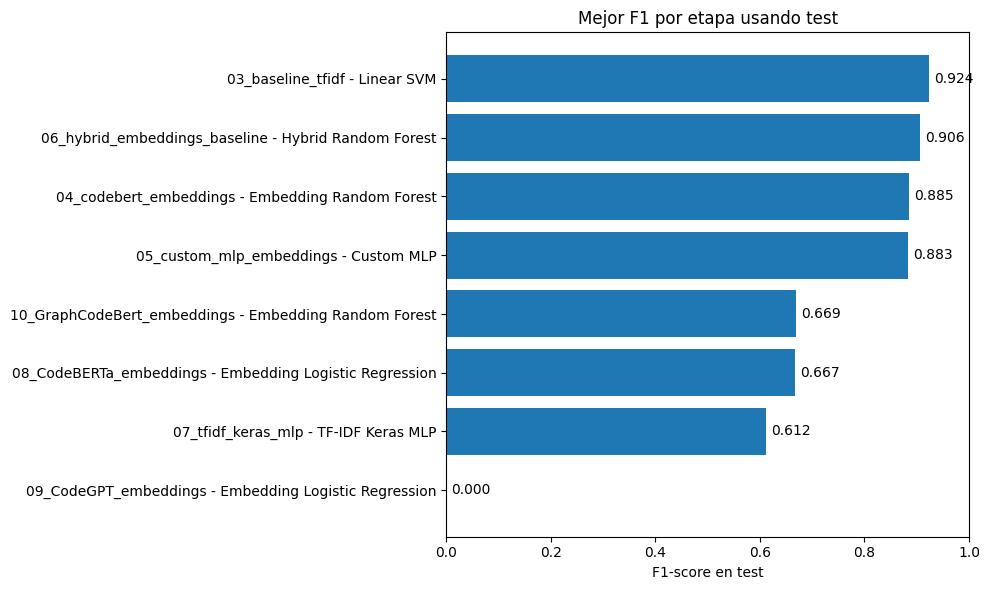

Paso 6.2: graficando métricas principales...


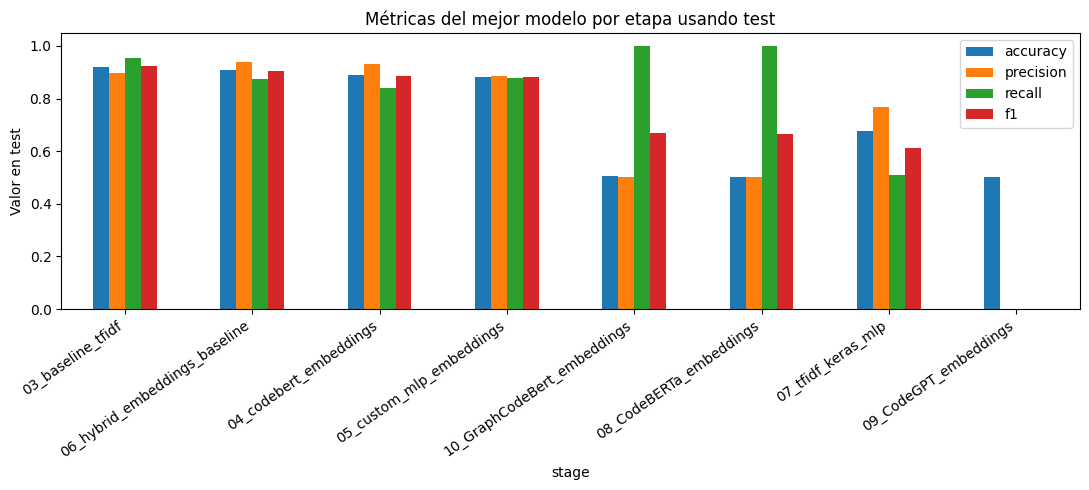

Paso 6.3: mostrando matrices de confusión...


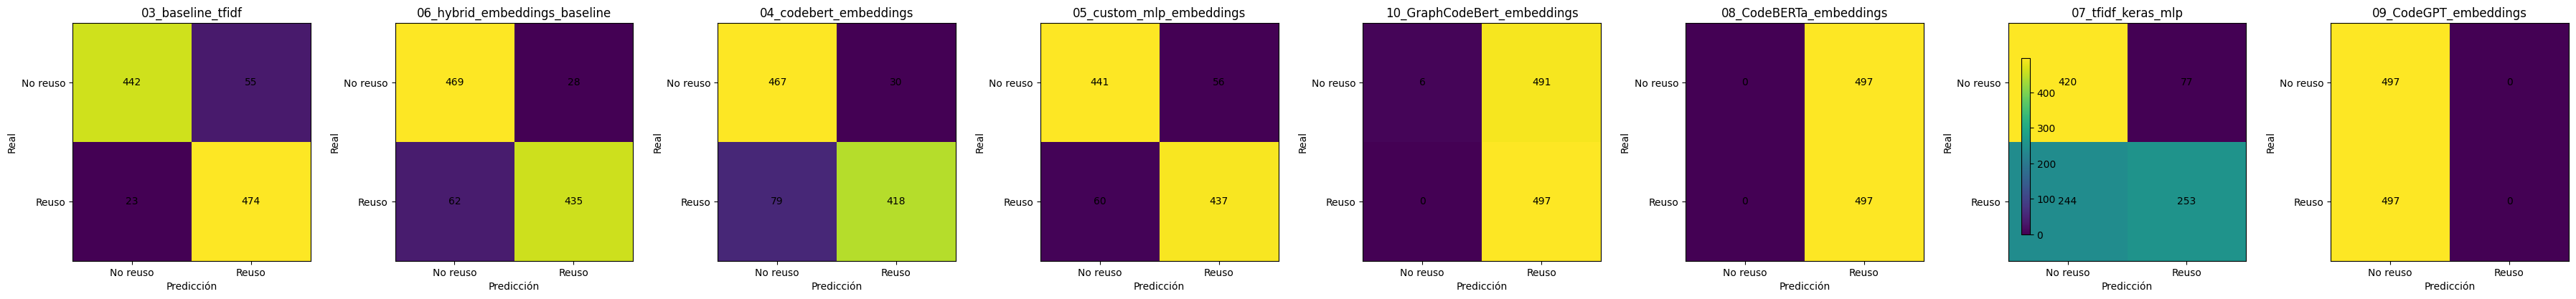

In [39]:
print('Paso 6.1: graficando F1 por etapa...')
plot_df = best_by_stage.sort_values('f1', ascending=True).copy()
labels = plot_df['stage'] + ' - ' + plot_df['model']

plt.figure(figsize=(10, 6))
plt.barh(labels, plot_df['f1'])
plt.xlabel('F1-score en test')
plt.title('Mejor F1 por etapa usando test')
plt.xlim(0, 1.0)
for idx, value in enumerate(plot_df['f1']):
    plt.text(min(value + 0.01, 0.98), idx, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()

print('Paso 6.2: graficando métricas principales...')
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
best_by_stage.set_index('stage')[metrics_to_plot].plot(kind='bar', figsize=(11, 5))
plt.ylim(0, 1.05)
plt.ylabel('Valor en test')
plt.title('Métricas del mejor modelo por etapa usando test')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('Paso 6.3: mostrando matrices de confusión...')
n_models = len(best_by_stage)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4))
if n_models == 1:
    axes = [axes]
for ax, row in zip(axes, best_by_stage.itertuples(index=False)):
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    im = ax.imshow(cm)
    ax.set_title(row.stage)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No reuso', 'Reuso'])
    ax.set_yticklabels(['No reuso', 'Reuso'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 7. Análisis de errores en TEST

Este paso une las predicciones de todos los modelos para responder dos preguntas:

1. Cuántos falsos positivos y falsos negativos tiene cada modelo.
2. Qué pares son difíciles porque varios modelos se equivocan en ellos.

Paso 7.1: uniendo predicciones disponibles...
Paso 7.2: calculando falsos positivos y falsos negativos...


,stage,false_positives,false_negatives,total_errors
0,03_baseline_tfidf,55,23,78
1,06_hybrid_embeddings_baseline,28,62,90
2,04_codebert_embeddings,30,79,109
3,05_custom_mlp_embeddings,56,60,116
4,07_tfidf_keras_mlp,77,244,321
5,10_GraphCodeBert_mlp,491,0,491
6,08_CodeBERTa_mlp,497,0,497
7,09_CodeGPT_mlp,0,497,497


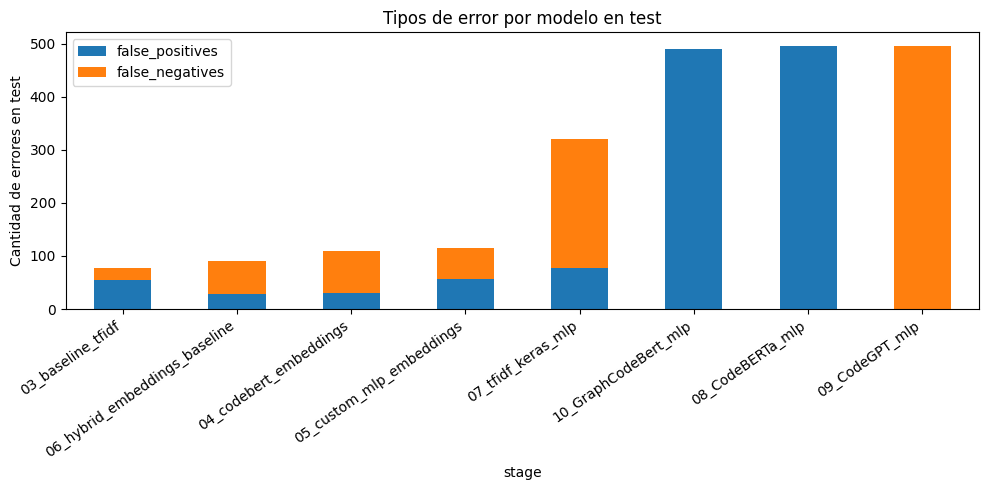

Paso 7.3: mostrando casos donde más modelos se equivocan...


,pair_id,language,file_1,file_2,true_label,n_models_correct,n_models_wrong,pred_03_baseline_tfidf,pred_04_codebert_embeddings,pred_05_custom_mlp_embeddings,pred_06_hybrid_embeddings_baseline,pred_07_tfidf_keras_mlp,pred_08_CodeBERTa_mlp,pred_09_CodeGPT_mlp,pred_10_GraphCodeBert_mlp
306,test_pair_000306,java,B11742,B13055,0,1,7,1,1,1,1,1,1,0,1
729,test_pair_000729,java,B11938,B12267,0,1,7,1,1,1,1,1,1,0,1
765,test_pair_000765,java,A11173,A10960,0,1,7,1,1,1,1,1,1,0,1
364,test_pair_000364,c,B10943,B11289,1,2,6,0,0,0,0,0,1,0,1
950,test_pair_000950,java,B11426,B12929,1,2,6,0,0,0,0,0,1,0,1
974,test_pair_000974,c,B10846,B11289,1,2,6,0,0,0,0,0,1,0,1
97,test_pair_000097,java,B20332,B20643,0,2,6,0,1,1,1,1,1,0,1
136,test_pair_000136,java,A21517,A20282,0,2,6,1,1,1,1,0,1,0,1
213,test_pair_000213,java,B11254,B12719,0,2,6,0,1,1,1,1,1,0,1
260,test_pair_000260,java,B21215,B22149,0,2,6,1,0,1,1,1,1,0,1


In [40]:
print('Paso 7.1: uniendo predicciones disponibles...')
prediction_specs = [
    ('03_baseline_tfidf', '03_test_predictions_baseline.csv'),
    ('04_codebert_embeddings', '04_test_predictions_transformer_embeddings.csv'),
    ('05_custom_mlp_embeddings', '05_custom_mlp_test_predictions.csv'),
    ('06_hybrid_embeddings_baseline', '06_hybrid_test_predictions.csv'),
    ('07_tfidf_keras_mlp', '07_tfidf_keras_test_predictions.csv'),
    ('08_CodeBERTa_mlp', '08_test_predictions_CodeBERTa_embeddings.csv'),
    ('09_CodeGPT_mlp', '09_test_predictions_CodeGPT_embeddings.csv'),
    ('10_GraphCodeBert_mlp', '10_test_predictions_GraphCodeBert_embeddings.csv'),
]
merged_predictions = None
for stage, file_name in prediction_specs:
    path = REPORTS_PATH / file_name
    if not path.exists():
        print('No encontrado:', file_name)
        continue
    df = pd.read_csv(path)
    temp = df[['pair_id', 'language', 'file_1', 'file_2', 'true_label', 'prediction']].copy().rename(columns={'prediction': f'pred_{stage}'})
    if merged_predictions is None:
        merged_predictions = temp
    else:
        merged_predictions = merged_predictions.merge(temp.drop(columns=['language', 'file_1', 'file_2', 'true_label']), on='pair_id', how='outer')

if merged_predictions is None:
    print('No hay predicciones de test para analizar errores.')
else:
    pred_cols = [col for col in merged_predictions.columns if col.startswith('pred_')]
    for col in pred_cols:
        merged_predictions[f'correct_{col}'] = (merged_predictions[col] == merged_predictions['true_label']).astype(int)
    correct_cols = [col for col in merged_predictions.columns if col.startswith('correct_')]
    merged_predictions['n_models_correct'] = merged_predictions[correct_cols].sum(axis=1)
    merged_predictions['n_models_wrong'] = len(correct_cols) - merged_predictions['n_models_correct']
    merged_predictions.to_csv(REPORTS_PATH / 'comparation_test_prediction_error_overlap.csv', index=False)

    print('Paso 7.2: calculando falsos positivos y falsos negativos...')
    error_summary = []
    for col in pred_cols:
        stage = col.replace('pred_', '')
        y_true = merged_predictions['true_label']
        y_pred = merged_predictions[col]
        mask = y_true.notna() & y_pred.notna()
        fp = int(((y_true[mask] == 0) & (y_pred[mask] == 1)).sum())
        fn = int(((y_true[mask] == 1) & (y_pred[mask] == 0)).sum())
        error_summary.append({'stage': stage, 'false_positives': fp, 'false_negatives': fn, 'total_errors': fp + fn})
    error_summary_df = pd.DataFrame(error_summary).sort_values('total_errors').reset_index(drop=True)
    error_summary_df.to_csv(REPORTS_PATH / 'comparation_test_error_summary.csv', index=False)
    display(error_summary_df)

    error_summary_df.set_index('stage')[['false_positives', 'false_negatives']].plot(kind='bar', stacked=True, figsize=(10, 5))
    plt.ylabel('Cantidad de errores en test')
    plt.title('Tipos de error por modelo en test')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

    print('Paso 7.3: mostrando casos donde más modelos se equivocan...')
    hard_cases = merged_predictions.sort_values(['n_models_wrong', 'true_label'], ascending=[False, False])
    display(hard_cases[['pair_id', 'language', 'file_1', 'file_2', 'true_label', 'n_models_correct', 'n_models_wrong'] + pred_cols].head(15))

## 8. Conclusión final

La selección final se basa exclusivamente en test: mayor F1, luego mayor recall, luego mayor precision y luego mayor accuracy.

Los archivos generados usan el prefijo `comparation_test` para no confundirse con reportes anteriores de validación.

In [41]:
print('Paso 8: mostrando el modelo final seleccionado.')
selected_model = all_candidates.sort_values(['f1', 'recall', 'precision', 'accuracy'], ascending=False).iloc[0].copy()
display(selected_model.to_frame(name='valor'))
print('Modelo seleccionado por TEST:', selected_model['model'])
print('Etapa:', selected_model['stage'])
print('F1 test:', round(selected_model['f1'], 4))
print('Recall test:', round(selected_model['recall'], 4))
print('Precision test:', round(selected_model['precision'], 4))

Paso 8: mostrando el modelo final seleccionado.


,valor
source_split,test
stage,03_baseline_tfidf
family,TF-IDF clásico
model,Linear SVM
accuracy,0.921529
precision,0.89603
recall,0.953722
f1,0.923977
tn,442
fp,55


Modelo seleccionado por TEST: Linear SVM
Etapa: 03_baseline_tfidf
F1 test: 0.924
Recall test: 0.9537
Precision test: 0.896
